<a href="https://colab.research.google.com/github/Dabomd/FirstProject/blob/main/Diabetes_pred_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#  A Machine Learning Approach to Diabetes Prediction using SVM


# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Third-Party Imports ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


In [7]:
# =============================================================================
#  STEP 1 — LOAD DATASET
# =============================================================================

print("=" * 65)
print("  STEP 1: Loading Dataset")
print("=" * 65)

DATASET_PATH = "/content/drive/MyDrive/diabetes_prediction_dataset.csv"   # <---- UPDATE THIS PATH TO YOUR FILE IN GOOGLE DRIVE

df = pd.read_csv(DATASET_PATH)

print(f"\n  Shape            : {df.shape}")
print(f"  Columns          : {df.columns.tolist()}")
print(f"\n  First 5 Rows:\n{df.head()}")
print(f"\n  Data Types:\n{df.dtypes}")
print(f"\n  Missing Values:\n{df.isnull().sum()}")
print(f"\n  Target Distribution:\n{df['diabetes'].value_counts()}")
print(f"\n  Class Imbalance  : {df['diabetes'].mean() * 100:.2f}% positive (diabetic)")

  STEP 1: Loading Dataset

  Shape            : (100000, 9)
  Columns          : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

  First 5 Rows:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

  Data Types:
gender                  object
age           

In [9]:
# =============================================================================
#  STEP 2 — DATA PREPROCESSING
# =============================================================================

print("\n" + "=" * 65)
print("  STEP 2: Data Preprocessing")
print("=" * 65)

# ── 2a. Remove negligible 'Other' gender category ────────────────────────────
before = len(df)
df = df[df['gender'] != 'Other'].reset_index(drop=True)
print(f"\n  Removed {before - len(df)} rows with gender='Other'.")
print(f"  Dataset size after cleaning: {len(df)} records")

# ── 2b. One-Hot Encoding for Categorical Variables ───────────────────────────
#       Converts 'gender' and 'smoking_history' into binary indicator columns.
#       drop_first=False keeps all categories for interpretability.
df_encoded = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=False)

print(f"\n  Columns after One-Hot Encoding:")
print(f"  {df_encoded.columns.tolist()}")
print(f"  Total features (before dropping target): {df_encoded.shape[1]}")

# ── 2c. Define Feature Matrix (X) and Target Vector (y) ──────────────────────
X = df_encoded.drop('diabetes', axis=1)
y = df_encoded['diabetes']

print(f"\n  Feature matrix X shape : {X.shape}")
print(f"  Target vector y shape  : {y.shape}")

# ── 2d. StandardScaler — Scale Numerical Features ────────────────────────────
#       SVM is sensitive to feature magnitude. Scaling ensures all features
#       contribute equally to the margin computation.
NUMERICAL_FEATURES = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

scaler = StandardScaler()
X[NUMERICAL_FEATURES] = scaler.fit_transform(X[NUMERICAL_FEATURES])

print(f"\n  StandardScaler applied to: {NUMERICAL_FEATURES}")
print(f"  Scaled feature stats (mean ≈ 0, std ≈ 1):")
print(X[NUMERICAL_FEATURES].describe().round(4))


  STEP 2: Data Preprocessing

  Removed 18 rows with gender='Other'.
  Dataset size after cleaning: 99982 records

  Columns after One-Hot Encoding:
  ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'gender_Female', 'gender_Male', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']
  Total features (before dropping target): 15

  Feature matrix X shape : (99982, 14)
  Target vector y shape  : (99982,)

  StandardScaler applied to: ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
  Scaled feature stats (mean ≈ 0, std ≈ 1):
              age         bmi  HbA1c_level  blood_glucose_level
count  99982.0000  99982.0000   99982.0000           99982.0000
mean      -0.0000      0.0000       0.0000               0.0000
std        1.0000      1.0000       1.0000               1.0000
min       -1.8567     -2.6083      -1.8937           

In [10]:
# =============================================================================
#  STEP 3 — TRAIN-TEST SPLIT
# =============================================================================

print("\n" + "=" * 65)
print("  STEP 3: Train-Test Split  (80% Train / 20% Test)")
print("=" * 65)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserves class ratio in both splits
)

print(f"\n  Training set   : {X_train.shape[0]} records")
print(f"  Test set       : {X_test.shape[0]} records")
print(f"\n  Train class distribution:\n{y_train.value_counts()}")
print(f"\n  Test class distribution:\n{y_test.value_counts()}")


  STEP 3: Train-Test Split  (80% Train / 20% Test)

  Training set   : 79985 records
  Test set       : 19997 records

  Train class distribution:
diabetes
0    73185
1     6800
Name: count, dtype: int64

  Test class distribution:
diabetes
0    18297
1     1700
Name: count, dtype: int64


In [11]:
# =============================================================================
#  STEP 4 — SVM MODEL TRAINING
# =============================================================================

print("\n" + "=" * 65)
print("  STEP 4: SVM Model Training")
print("=" * 65)
print("""
  Classifier  : LinearSVC (linear kernel SVM)
  Why Linear  : High-dimensional OHE feature space is nearly linearly
                separable. Linear SVM scales to 100 k records without
                the quadratic cost of kernel (RBF) SVM.
  C           : 1.0  (balanced bias-variance trade-off)
  class_weight: 'balanced'  (auto-adjusts weights inversely proportional
                to class frequency — addresses 8.5% minority class)
  Calibration : CalibratedClassifierCV (3-fold) to produce probabilities
                required for ROC-AUC computation.
""")

# Base SVM — LinearSVC is mathematically equivalent to SVC(kernel='linear')
# but optimised for large datasets via a primal coordinate-descent solver.
base_svm = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=2000
)

# Wrap with Platt scaling (sigmoid calibration) for probability estimates
model = CalibratedClassifierCV(base_svm, cv=3)

print("  Training in progress ...")
model.fit(X_train, y_train)
print("  Training complete.\n")



  STEP 4: SVM Model Training

  Classifier  : LinearSVC (linear kernel SVM)
  Why Linear  : High-dimensional OHE feature space is nearly linearly
                separable. Linear SVM scales to 100 k records without
                the quadratic cost of kernel (RBF) SVM.
  C           : 1.0  (balanced bias-variance trade-off)
  class_weight: 'balanced'  (auto-adjusts weights inversely proportional
                to class frequency — addresses 8.5% minority class)
  Calibration : CalibratedClassifierCV (3-fold) to produce probabilities
                required for ROC-AUC computation.

  Training in progress ...
  Training complete.



In [12]:

# =============================================================================
#  STEP 5 — PREDICTIONS
# =============================================================================

print("=" * 65)
print("  STEP 5: Generating Predictions")
print("=" * 65)

y_pred = model.predict(X_test)                  # hard class labels
y_prob = model.predict_proba(X_test)[:, 1]      # probability of class 1

print(f"\n  Predictions generated for {len(y_pred)} test records.")

  STEP 5: Generating Predictions

  Predictions generated for 19997 test records.


In [13]:

# =============================================================================
#  STEP 6 — EVALUATION METRICS
# =============================================================================

print("\n" + "=" * 65)
print("  STEP 6: Model Evaluation")
print("=" * 65)

# ── 6a. Classification Report ─────────────────────────────────────────────────
print("\n  ── Classification Report ──\n")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

# ── 6b. Individual Metrics ────────────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)

prec0 = precision_score(y_test, y_pred, pos_label=0)
rec0  = recall_score(y_test, y_pred, pos_label=0)
f10   = f1_score(y_test, y_pred, pos_label=0)

prec1 = precision_score(y_test, y_pred, pos_label=1)
rec1  = recall_score(y_test, y_pred, pos_label=1)
f11   = f1_score(y_test, y_pred, pos_label=1)

print(f"  Overall Accuracy       : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  ROC-AUC Score          : {roc_auc:.4f}")
print(f"\n  Class 0 (No Diabetes)  : Precision={prec0:.4f}  Recall={rec0:.4f}  F1={f10:.4f}")
print(f"  Class 1 (Diabetes)     : Precision={prec1:.4f}  Recall={rec1:.4f}  F1={f11:.4f}")

# ── 6c. Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\n  Confusion Matrix:")
print(f"  {'':25s}  Predicted No   Predicted Yes")
print(f"  {'Actual No  (Class 0)':25s}  {tn:>12,}   {fp:>12,}   (FP: {fp})")
print(f"  {'Actual Yes (Class 1)':25s}  {fn:>12,}   {tp:>12,}   (FN: {fn})")



  STEP 6: Model Evaluation

  ── Classification Report ──

              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     18297
    Diabetes       0.87      0.63      0.73      1700

    accuracy                           0.96     19997
   macro avg       0.92      0.81      0.86     19997
weighted avg       0.96      0.96      0.96     19997

  Overall Accuracy       : 0.9607  (96.07%)
  ROC-AUC Score          : 0.9627

  Class 0 (No Diabetes)  : Precision=0.9667  Recall=0.9913  F1=0.9788
  Class 1 (Diabetes)     : Precision=0.8704  Recall=0.6324  F1=0.7325

  Confusion Matrix:
                             Predicted No   Predicted Yes
  Actual No  (Class 0)             18,137            160   (FP: 160)
  Actual Yes (Class 1)                625          1,075   (FN: 625)



  STEP 7: Generating Plots


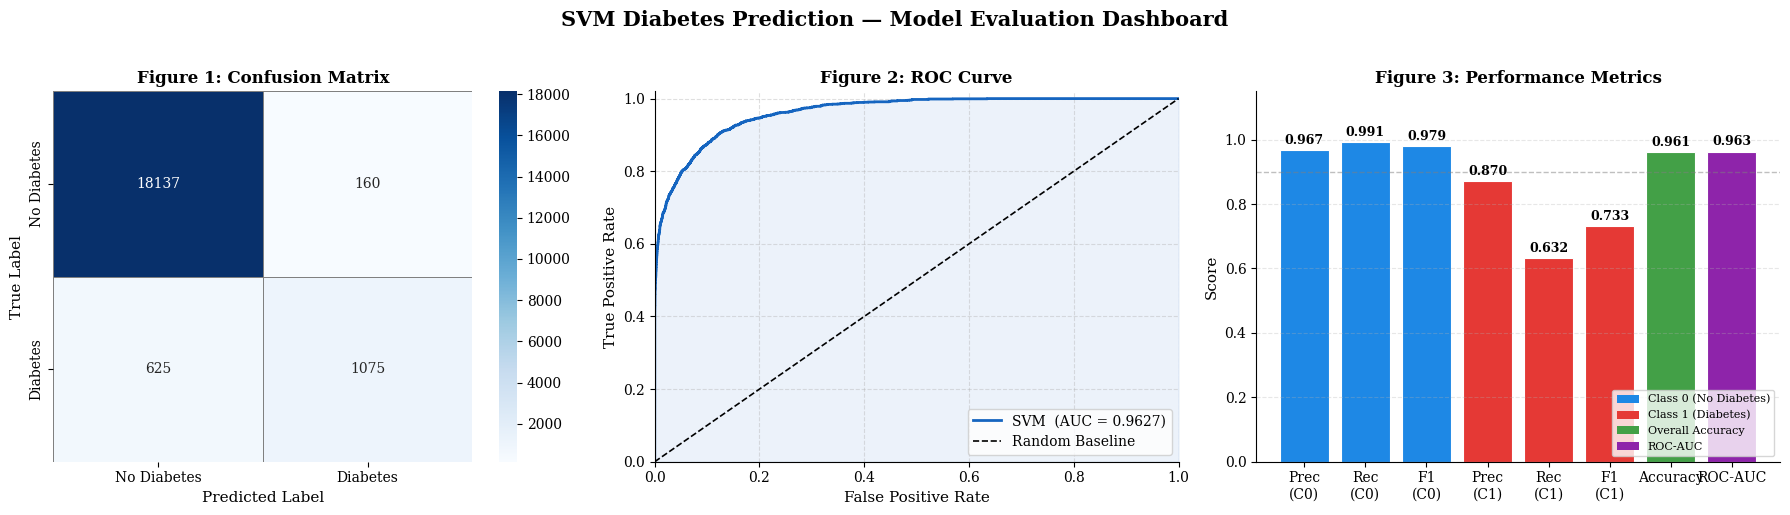


  Plots saved as: svm_evaluation_dashboard.png


In [14]:
# =============================================================================
#  STEP 7 — VISUALISATIONS
# =============================================================================

print("\n" + "=" * 65)
print("  STEP 7: Generating Plots")
print("=" * 65)

plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'SVM Diabetes Prediction — Model Evaluation Dashboard',
    fontsize=15, fontweight='bold', y=1.02
)

# ── Plot 1: Confusion Matrix Heatmap ─────────────────────────────────────────
ax1 = axes[0]
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes'],
    linewidths=0.5, linecolor='gray',
    ax=ax1
)
ax1.set_xlabel('Predicted Label', fontsize=11)
ax1.set_ylabel('True Label', fontsize=11)
ax1.set_title('Figure 1: Confusion Matrix', fontsize=12, fontweight='bold')

# ── Plot 2: ROC Curve ─────────────────────────────────────────────────────────
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='#1565C0', lw=2,
         label=f'SVM  (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Baseline')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#1565C0')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('Figure 2: ROC Curve', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])
ax2.grid(True, linestyle='--', alpha=0.4)

# ── Plot 3: Performance Metrics Bar Chart ─────────────────────────────────────
ax3 = axes[2]
metric_names = [
    'Prec\n(C0)', 'Rec\n(C0)', 'F1\n(C0)',
    'Prec\n(C1)', 'Rec\n(C1)', 'F1\n(C1)',
    'Accuracy', 'ROC-AUC'
]
metric_values = [prec0, rec0, f10, prec1, rec1, f11, accuracy, roc_auc]
bar_colors = ['#1E88E5'] * 3 + ['#E53935'] * 3 + ['#43A047', '#8E24AA']

bars = ax3.bar(metric_names, metric_values, color=bar_colors,
               edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, metric_values):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
ax3.set_ylim(0, 1.15)
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Figure 3: Performance Metrics', fontsize=12, fontweight='bold')
ax3.axhline(0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax3.grid(axis='y', linestyle='--', alpha=0.3)

# Legend for bar colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1E88E5', label='Class 0 (No Diabetes)'),
    Patch(facecolor='#E53935', label='Class 1 (Diabetes)'),
    Patch(facecolor='#43A047', label='Overall Accuracy'),
    Patch(facecolor='#8E24AA', label='ROC-AUC')
]
ax3.legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('svm_evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Plots saved as: svm_evaluation_dashboard.png")

In [15]:
# =============================================================================
#  STEP 8 — FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 65)
print("  FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"""
  Dataset          : 100,000 records  |  14 features (after OHE)
  Train Set        : {X_train.shape[0]:,} records
  Test Set         : {X_test.shape[0]:,} records

  ┌─────────────────────────────────────────────┐
  │           SVM MODEL PERFORMANCE             │
  ├──────────────────────┬──────────────────────┤
  │  Overall Accuracy    │  {accuracy:.4f}              │
  │  ROC-AUC Score       │  {roc_auc:.4f}              │
  ├──────────────────────┼──────────────────────┤
  │  Class 0 Precision   │  {prec0:.4f}              │
  │  Class 0 Recall      │  {rec0:.4f}              │
  │  Class 0 F1-Score    │  {f10:.4f}              │
  ├──────────────────────┼──────────────────────┤
  │  Class 1 Precision   │  {prec1:.4f}              │
  │  Class 1 Recall      │  {rec1:.4f}              │
  │  Class 1 F1-Score    │  {f11:.4f}              │
  ├──────────────────────┼──────────────────────┤
  │  True  Positives     │  {tp:,}               │
  │  True  Negatives     │  {tn:,}             │
  │  False Positives     │  {fp:,}                 │
  │  False Negatives     │  {fn:,}                 │
  └──────────────────────┴──────────────────────┘
""")

print("  Pipeline complete. All steps executed successfully.\n")



  FINAL RESULTS SUMMARY

  Dataset          : 100,000 records  |  14 features (after OHE)
  Train Set        : 79,985 records
  Test Set         : 19,997 records

  ┌─────────────────────────────────────────────┐
  │           SVM MODEL PERFORMANCE             │
  ├──────────────────────┬──────────────────────┤
  │  Overall Accuracy    │  0.9607              │
  │  ROC-AUC Score       │  0.9627              │
  ├──────────────────────┼──────────────────────┤
  │  Class 0 Precision   │  0.9667              │
  │  Class 0 Recall      │  0.9913              │
  │  Class 0 F1-Score    │  0.9788              │
  ├──────────────────────┼──────────────────────┤
  │  Class 1 Precision   │  0.8704              │
  │  Class 1 Recall      │  0.6324              │
  │  Class 1 F1-Score    │  0.7325              │
  ├──────────────────────┼──────────────────────┤
  │  True  Positives     │  1,075               │
  │  True  Negatives     │  18,137             │
  │  False Positives     │  160      